In [8]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

In [9]:

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (20, 10),
    "figure.dpi": 110,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 1
})

In [ ]:
X,Y=np.meshgrid(np.linspace(-5,5,500),np.linspace(-5,5,500))
Z=X**2+Y**2
fig = go.Figure(
        data=[
            go.Surface(x=X,y=Y,z=Z,colorscale='emrld')
            
        ] )
fig.update_layout(
    width=900,   
    height=800,  
)
fig.show()




In [ ]:
#algo
#theta=theta-n*grad(f)
#grad(f)=[[2x],
#         [2y]]
# 
def gradient_descent(T,theta,n):
    theta=theta 
    theta_x=[]
    theta_y=[]
    for _ in range(T):
        X0=2*np.array([theta[0]/(np.sqrt(theta[0]**2+theta[1]**2)),
                    theta[1]/(np.sqrt(theta[0]**2+theta[1]**2))])
        

        theta=theta-n*X0
        theta_x.append(theta[0])
        theta_y.append(theta[1])
        
    graph(theta_x,theta_y) 
   
       
        
    return theta[0]**2+theta[1]**2     
        

def graph(theta_x,theta_y):
        X,Y=np.meshgrid(np.linspace(-5,5,500),np.linspace(-5,5,500))
        Z=X**2+Y**2
        
        fig = go.Figure(data=[
            go.Surface(x=X,y=Y,z=Z,colorscale='emrld'),
            go.Scatter3d(x=theta_x,y=theta_y,z=np.array(theta_x)**2+np.array(theta_y)**2,mode='lines+markers',line=dict(width=15),marker=dict(size=8))
            ] )
        fig.update_layout(width=900,height=800)
        
        fig.show()


        

print(gradient_descent(8,np.array([4.5,4.6]),0.4))    

In [12]:
def sigmoid(z):
    return 1/(1+np.e**-z)

def cross_entropy_loss(X,Y,THETA):
    return -np.mean(Y*np.log(sigmoid(aug(X) @ THETA))+(1-Y)*np.log(1-sigmoid(aug(X) @ THETA)))

def aug(X):
    new_col=np.ones((X.shape[0],1))
    return np.hstack((X,new_col))

def gradient(X,Y,THETA):
    return np.mean(aug(X)*(sigmoid(aug(X) @ THETA)-Y),axis=0)

def x_y_plot(theta_arr):
    y = np.empty((len(theta_arr),2))
    x = np.array([[4,7.5]]*len(theta_arr))

    for i in range(len(x)):
        y[i] = -(theta_arr[i,0]*x[i]+theta_arr[i,2])/theta_arr[i,1]
    
    return x ,y 

def plot_graph(a , b, c, d ,theta_arr ,f ):
    x ,y = x_y_plot(theta_arr)
    plt.scatter(a ,b , label = 'setosa', color = 'black')
    plt.scatter(c ,d , label = 'versicolor', color = 'red')
    for  i,(xi , yi) in enumerate(zip(x ,y )):
        if i % (f) == 0:
            
            plt.plot(xi , yi , 'b-' , linewidth = 2)
            
    plt.plot(x[0] ,y[0] , 'r--' , linewidth = 2 , label = 'starting line')
    plt.xlabel('Sepal_Length')
    plt.ylabel('Sepal_Width')
    plt.legend(fontsize = 20)
    plt.grid(True)    
    plt.ylim(1.5 , 4.5)
    plt.xlim(4 , 7.5)
    plt.show()  


In [13]:
'''
   X=np.array([[1,2],[4,5],[6,7],[5,2]])  #4x2 dx2
   aug(X)                                 #4x3 dx3
   Y=np.array([[1],[1],[0],[0]])          #4x1 dx1
   THETA=np.array([[0],[0],[0]])          #3x1 
'''


'\n   X=np.array([[1,2],[4,5],[6,7],[5,2]])  #4x2 dx2\n   aug(X)                                 #4x3 dx3\n   Y=np.array([[1],[1],[0],[0]])          #4x1 dx1\n   THETA=np.array([[0],[0],[0]])          #3x1 \n'

In [14]:
data=pd.read_csv('iris_data.csv')
df=pd.DataFrame(data)
x=df.iloc[:,0:2]

X=np.array(x)
Y=np.array([1]*50+[0]*50)
main_Y=Y.reshape([100,1])

THETA=np.zeros((3,1))

setosa=df[df['species']=='setosa']

versicolour=df[df['species']=='versicolor']

ssl = np.array([setosa['sepal_length']])
ssw = np.array([setosa['sepal_width']])
vsl = np.array([versicolour['sepal_length']])
vsw = np.array([versicolour['sepal_width']])

steps = 1000
lr = 0.8099



# Stochastic_GD

In [15]:
def  Stochastic_GD(THETA , X ,Y , r , steps): 
    theta_arr = np.empty((steps , 3))  
    THETA     = THETA
    for i in range(steps):
        random_index = np.random.randint(len(X))
        THETA = THETA - r*gradient(X[[random_index]],Y[[random_index]],THETA).reshape([-1,1])
        theta_arr[i] = THETA.ravel()


    return THETA , theta_arr

steps = 1000
r = 0.1
THETA_sgd , theta_arr = Stochastic_GD(THETA=THETA , X=X , Y=main_Y, r=r, steps=steps) 


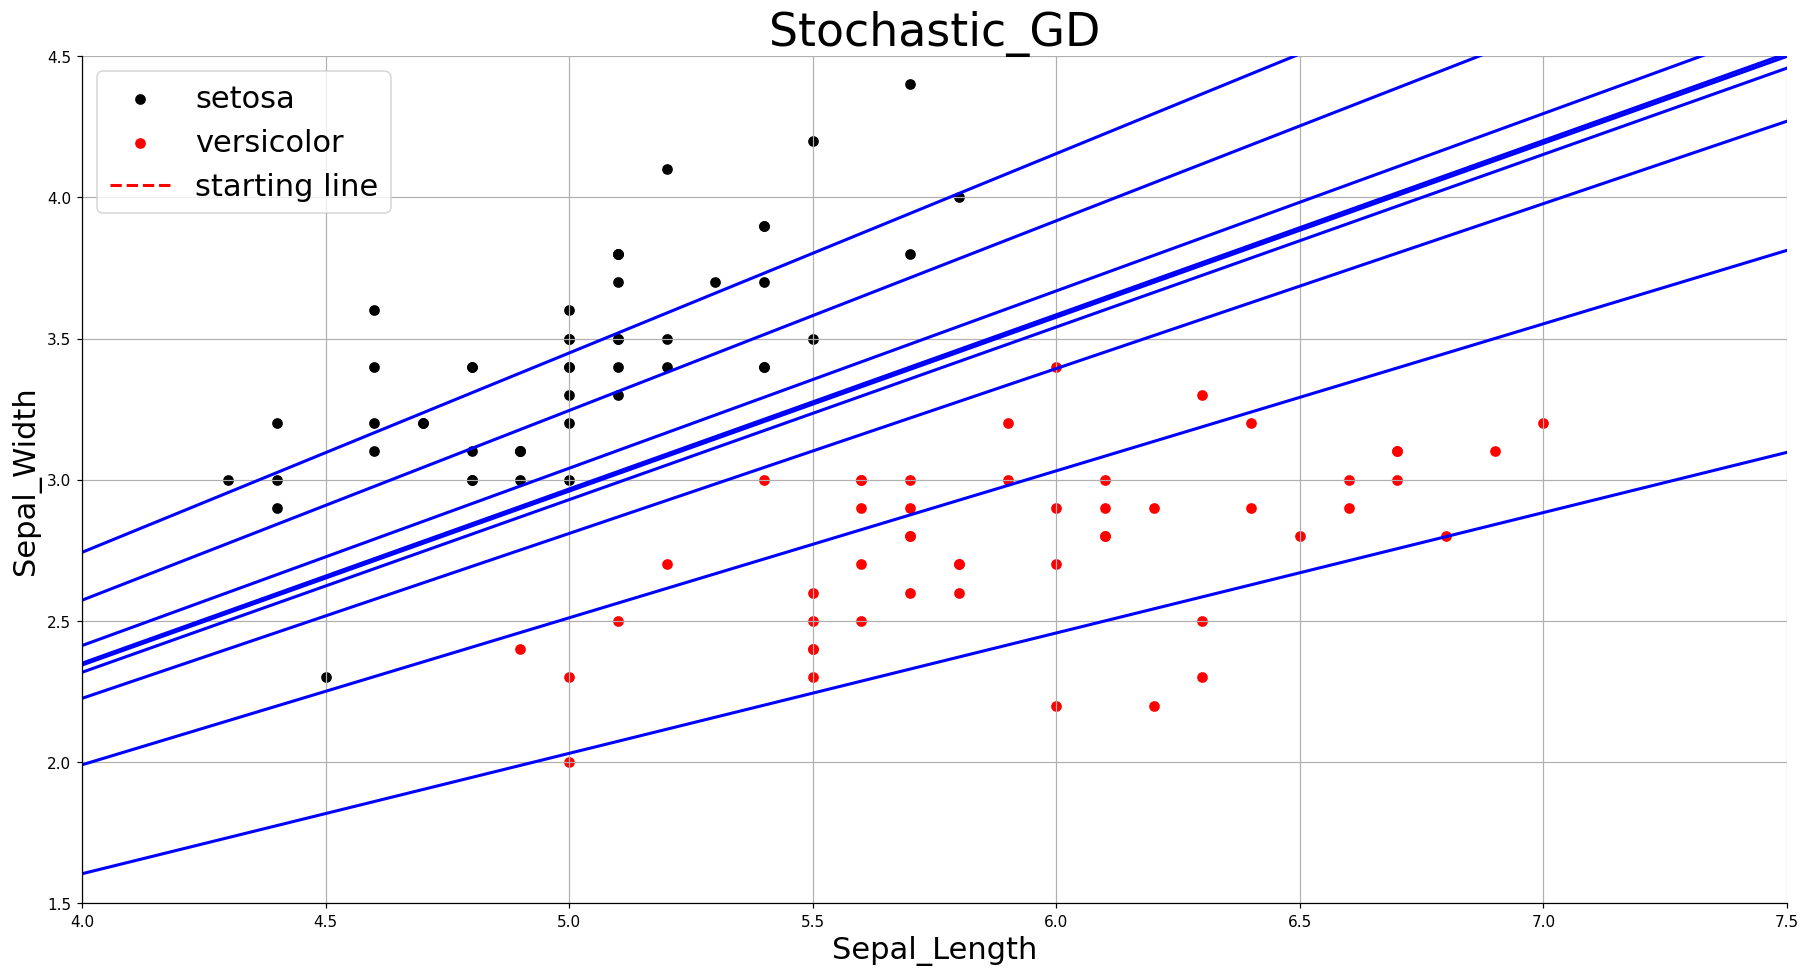

In [16]:
plt.title('Stochastic_GD' , fontsize = 30)
plot_graph(a= ssl , b= ssw , c = vsl , d =vsw , theta_arr= theta_arr , f= 100)

In [34]:
best_theta_sgd = theta_arr[-1]
best_theta_sgd


array([-3.3692285 ,  5.57790764,  0.71583086])

# Batch_GD

In [17]:
def Batch_GD(X,Y,THETA,steps,r):
    theta_arr = np.empty((steps , 3))
    THETA=THETA
    for _ in range(steps):

        THETA = THETA - r*gradient(X,Y,THETA).reshape([-1,1])
        theta_arr[_] = THETA.ravel()
           
           

    return THETA , theta_arr


THETA = np.zeros((3,1))
lr = 0.01
steps = 10000
THETA_batch , theta_arr_batch   = Batch_GD(X, main_Y ,THETA=THETA ,  steps= steps , r= lr)

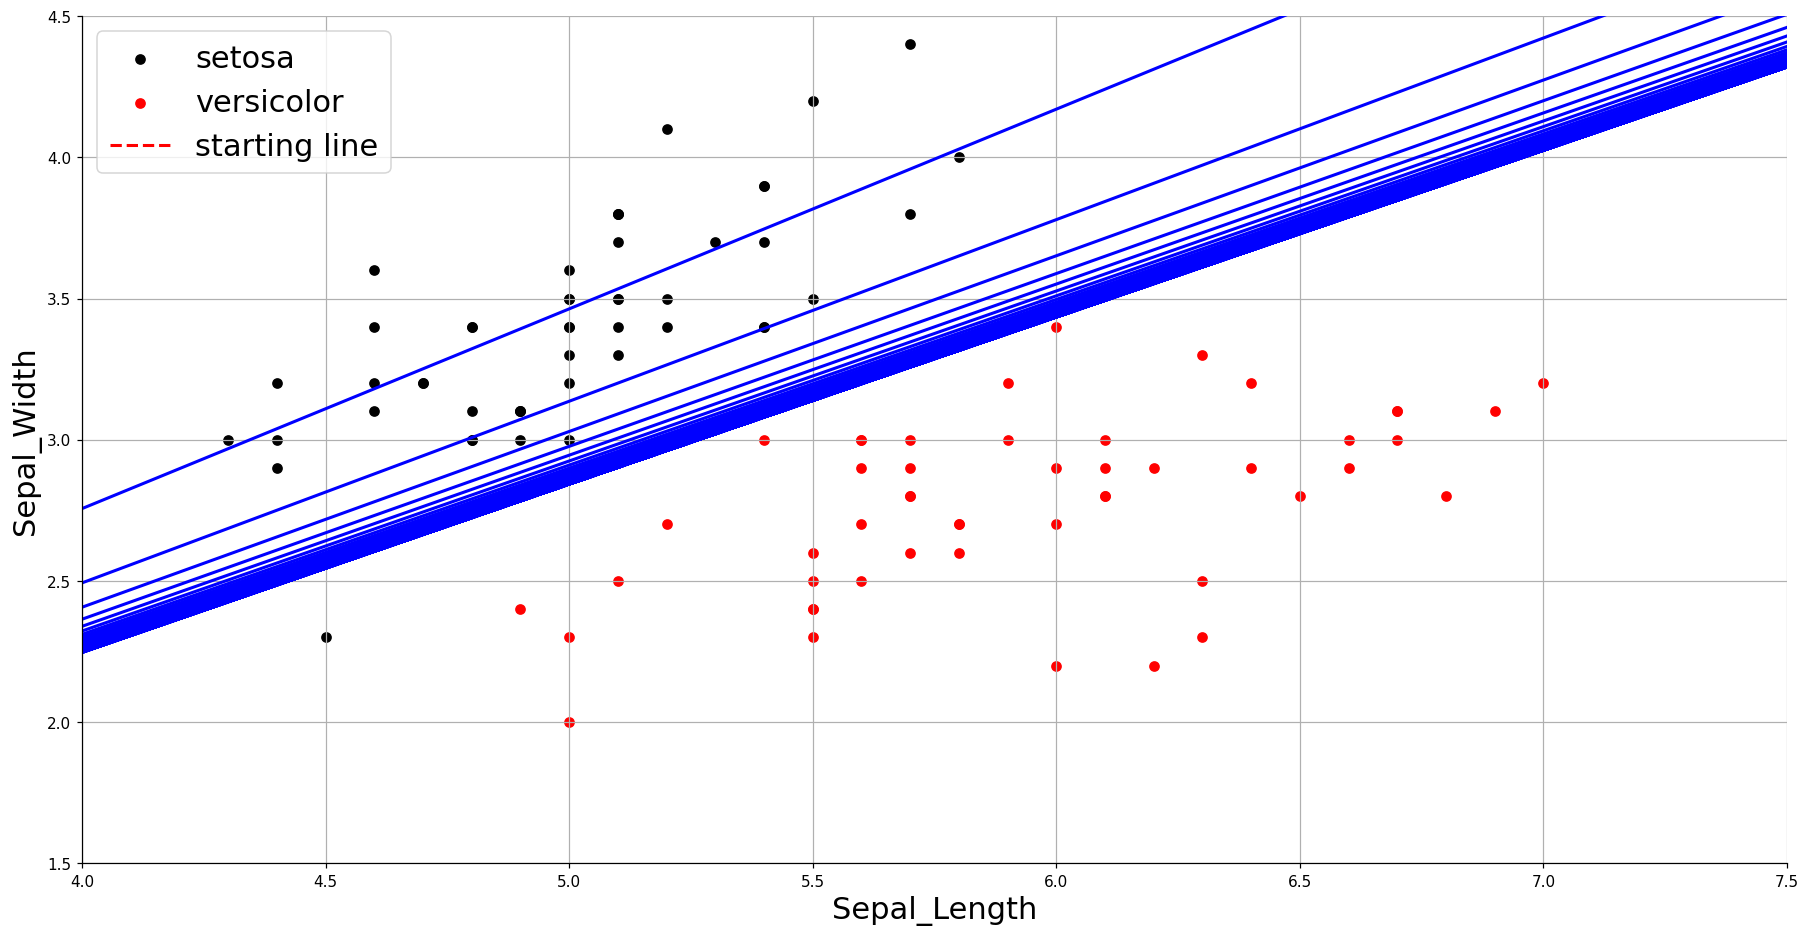

In [18]:

plot_graph(a= ssl , b= ssw , c = vsl , d =vsw , theta_arr= theta_arr_batch , f= 50)


In [27]:
best_theta_batch = theta_arr_batch[-1]
best_theta_batch

array([-3.04714971,  5.10943662,  0.70846899])

# Mini_Batch_GD

In [ ]:
def  Mini_Batch_GD(THETA , X ,Y , r , steps , num ): 

    theta_arr = np.empty((steps , 3))  
    THETA     = THETA
    for i in range(steps):
        random_batch = np.random.randint(0,len(X), num)
        THETA = THETA - r*gradient(X[random_batch],Y[random_batch],THETA).reshape([-1,1])
        theta_arr[i] = THETA.ravel()

    return THETA , theta_arr

 

In [20]:

THETA = np.zeros((3,1))
steps = 1000
lr = 0.1
n_samples = 30
THETA_mini_batch , theta_arr_mini_batch = Mini_Batch_GD(THETA= THETA , X = X,Y =main_Y , r = lr  , steps = steps , num = n_samples)


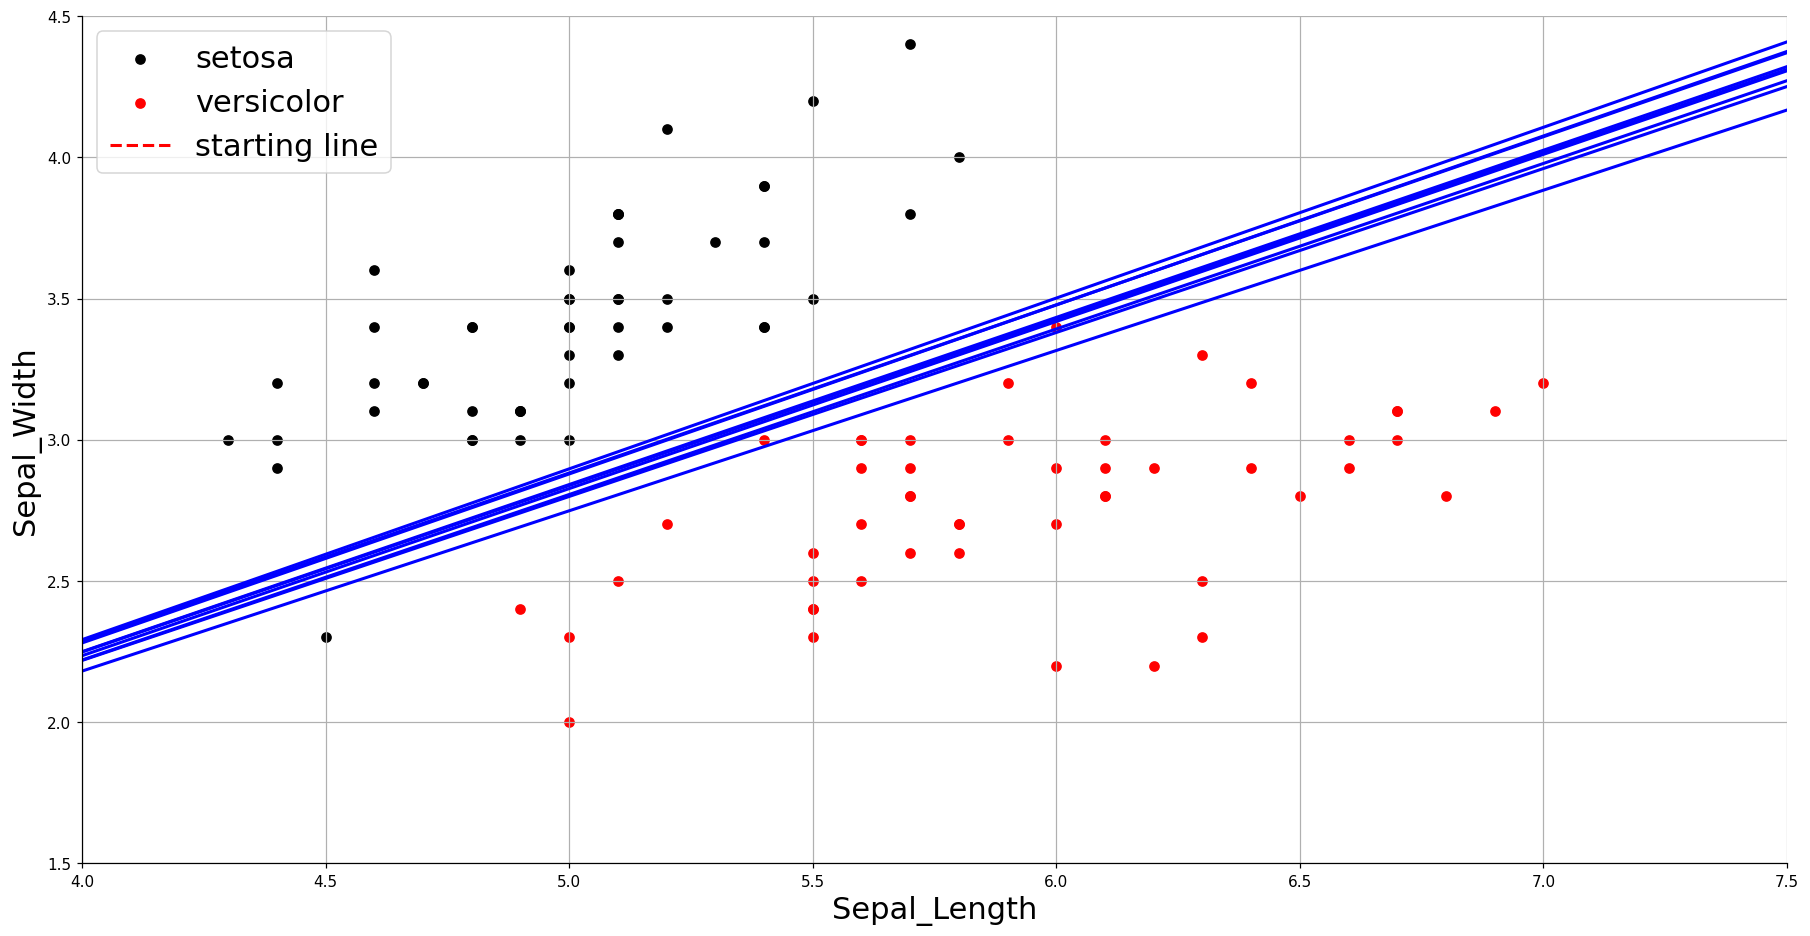

In [21]:

plot_graph(a =ssl  ,b =ssw , c = vsl ,  d = vsw , 
           theta_arr = theta_arr_mini_batch  ,f = 100)


In [29]:
best_theta_mini_batch = theta_arr_mini_batch[-1]
best_theta_mini_batch

array([-3.04046905,  5.13709592,  0.70872668])

In [31]:
# Pacing of each algorithms 
theta_ratio_sgd = theta_arr[: , [0 , 2]] / theta_arr[ : , [1]]
theta_ratio_batch = theta_arr_batch[: , [0 , 2]] / theta_arr_batch[ : , [1]]
theta_ratio_mini_batch = theta_arr_mini_batch[: , [0 , 2]] / theta_arr_mini_batch[ : , [1]]


(-0.3, 0.2)

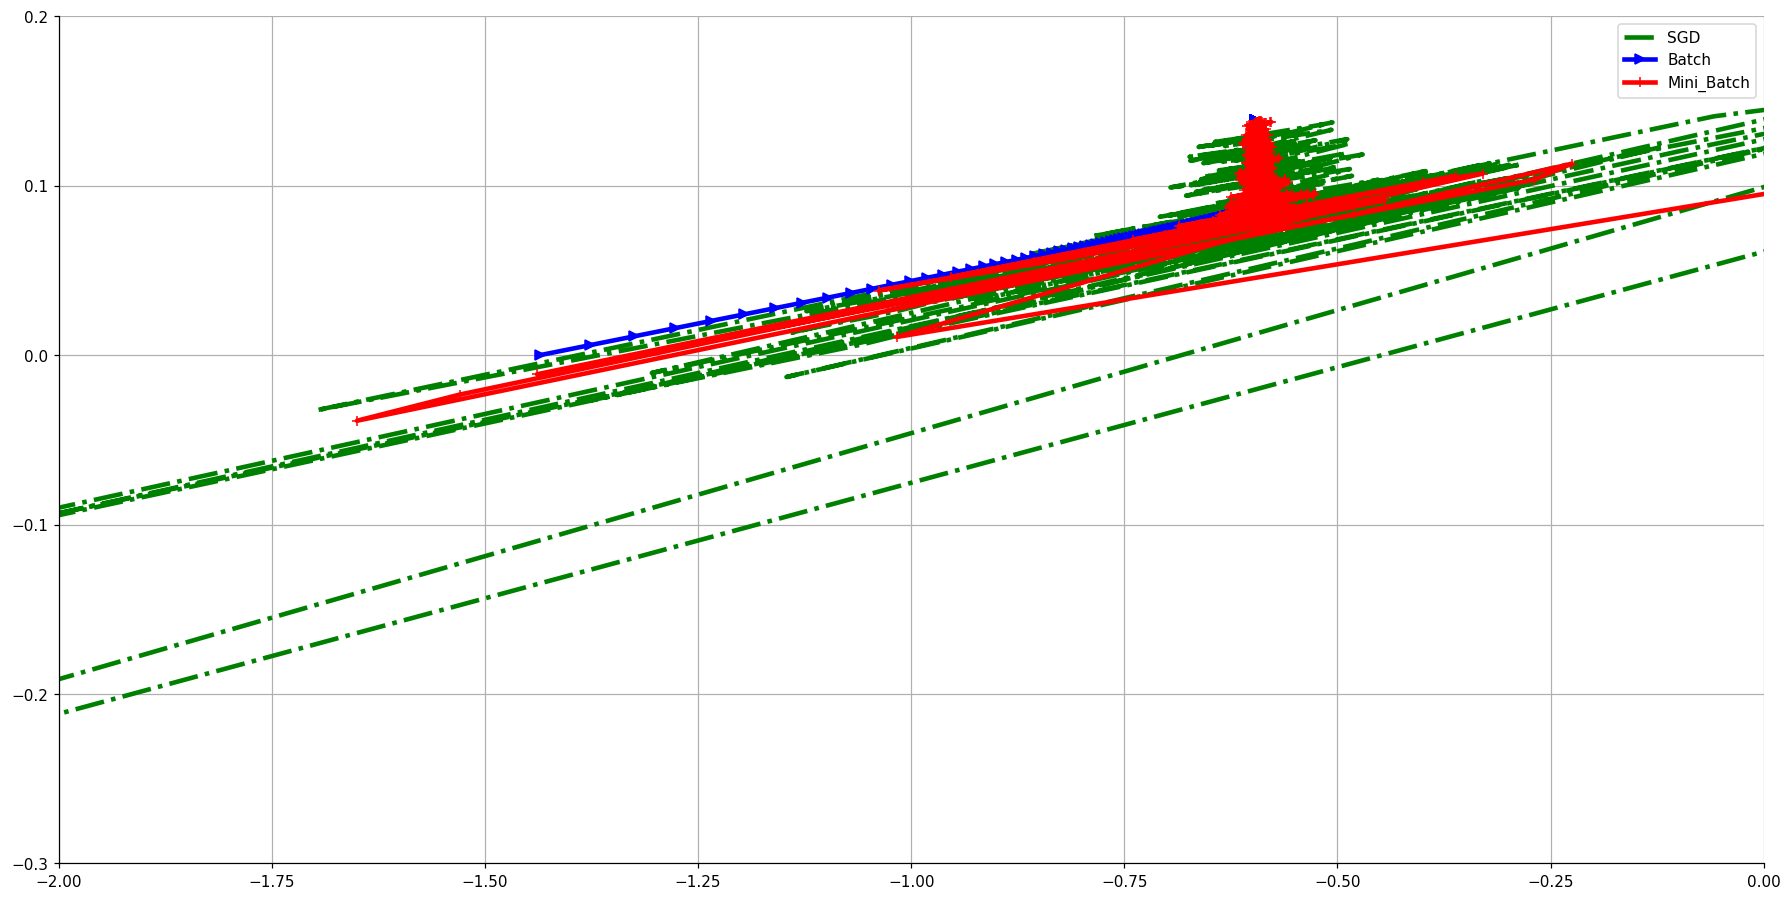

In [65]:
plt.grid(True)
plt.plot(theta_ratio_sgd[: , 0].flatten() , theta_ratio_sgd[: , 1].flatten()
          , "g-." , linewidth = 3 , label = "SGD")
plt.plot(theta_ratio_batch[: , 0].flatten() , theta_ratio_batch[: , 1].flatten()
          , "b->" , linewidth = 3 , label = "Batch")
plt.plot(theta_ratio_mini_batch[: , 0].flatten() , theta_ratio_mini_batch[: , 1].flatten()
          , "r-+" , linewidth = 3 , label = "Mini_Batch")

plt.legend()
plt.xlim((-2 , 0))
plt.ylim((-0.3 , 0.2))